In [1]:
import numpy as np
import tensorcircuit as tc

tc.set_backend("jax")
print("OK")

OK


TensorCircuit Es un framework de tensores que interpreta circuitos cuánticos

Un circuito cuántico = una red tensorial

Cada puerta = tensor___El circuito = grafo de tensores___Simular = contraer la red

The most common case and the most typical programming paradigm for TensorCircuit are to evaluate the circuit output and the corresponding quantum gradients, which is common in variational quantum algorithms.

In [2]:
import tensorcircuit as tc

K = tc.set_backend("tensorflow")

n = 1


def loss(params, n):
    c = tc.Circuit(n)
    for i in range(n):
        c.rx(i, theta=params[0, i])
    for i in range(n):
        c.rz(i, theta=params[1, i])
    loss = 0.0
    for i in range(n):
        loss += c.expectation([tc.gates.z(), [i]])
    return K.real(loss)


vgf = K.jit(K.value_and_grad(loss), static_argnums=1)
params = K.implicit_randn([2, n])
print(vgf(params, n))  # get the quantum loss and the gradient

(<tf.Tensor: shape=(), dtype=float32, numpy=0.9997478723526001>, <tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.2455541e-02],
       [2.9802322e-08]], dtype=float32)>)


TensorCircuit tiene dos objetos clave:

MPS → estado cuántico comprimido
→ tc.QuVector

MPO → operador (Hamiltoniano, puertas, etc.)
→ tc.QuOperator

c = tc.Circuit(n, mps_inputs=w)____En lugar de empezar en |0⟩^N, empiezas desde un estado MPS arbitrario (como DMRG)

In [3]:
n = 3
nodes = [tc.gates.Gate(np.array([0.0, 1.0])) for _ in range(n)]
mps = tc.quantum.QuVector([nd[0] for nd in nodes])
c = tc.Circuit(n, mps_inputs=mps)
c.x(0)
c.expectation_ps(z=[0])
# 1.0

<tf.Tensor: shape=(), dtype=complex64, numpy=(1+0j)>

q = c.quvector()____obtienes el estado final como MPS sin contraerlo a vector completo. Puedes hacer: overlaps, fidelidades, expectativas, Sin explotar exponencialmente

MPO como gate: c.mpo(0, 1, mpo=mpo), En vez de aplicar una puerta normal:
c.cnot(0,1), usas un operador en forma MPO.

In [5]:
import tensorcircuit as tc
import tensorflow as tf
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
import random

K = tc.set_backend("tensorflow")

nlayers = 3  # the number of layers
ncircuits = 6  # six circuits with different initial parameters are going to be optimized at the same time
nnodes = 8  # the number of nodes

MaxCut

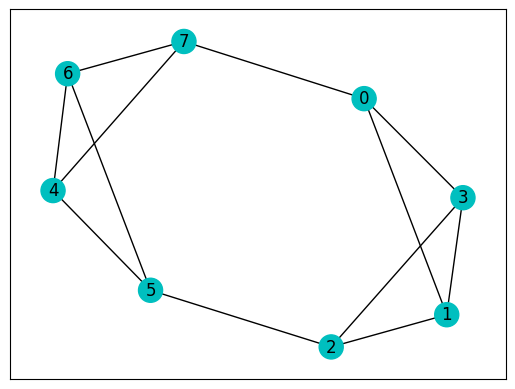

In [6]:
# a graph instance
# each node is connected to three nodes
# for example, node 0 is connected to nodes 1,7,3
example_graph_dict = {
    0: {1: {"weight": 1.0}, 7: {"weight": 1.0}, 3: {"weight": 1.0}},
    1: {0: {"weight": 1.0}, 2: {"weight": 1.0}, 3: {"weight": 1.0}},
    2: {1: {"weight": 1.0}, 3: {"weight": 1.0}, 5: {"weight": 1.0}},
    3: {1: {"weight": 1.0}, 2: {"weight": 1.0}, 0: {"weight": 1.0}},
    4: {7: {"weight": 1.0}, 6: {"weight": 1.0}, 5: {"weight": 1.0}},
    5: {6: {"weight": 1.0}, 4: {"weight": 1.0}, 2: {"weight": 1.0}},
    6: {7: {"weight": 1.0}, 4: {"weight": 1.0}, 5: {"weight": 1.0}},
    7: {4: {"weight": 1.0}, 6: {"weight": 1.0}, 0: {"weight": 1.0}},
}
pos = nx.spring_layout(nx.to_networkx_graph(example_graph_dict))
colors = ["c" for key in example_graph_dict.items()]

# convert to a NetworkX graph
example_graph = nx.to_networkx_graph(example_graph_dict)
nx.draw_networkx(example_graph, with_labels=True, node_color=colors, pos=pos)
ax = plt.gca()
ax.set_facecolor("w")

Parameterized Quantum Circuit (PQC)

In [7]:
def QAOAansatz(params, g=example_graph, return_circuit=False):
    n = len(g.nodes)  # the number of nodes
    c = tc.Circuit(n)
    for i in range(n):
        c.H(i)

    # PQC
    for j in range(nlayers):
        # U_j
        for e in g.edges:
            c.exp1(
                e[0],
                e[1],
                unitary=tc.gates._zz_matrix,
                theta=g[e[0]][e[1]].get("weight", 1.0) * params[2 * j],
            )
        # V_j
        for i in range(n):
            c.rx(i, theta=params[2 * j + 1])

    # whether to return the circuit
    if return_circuit is True:
        return c

    # calculate the loss function
    loss = 0.0
    for e in g.edges:
        loss += c.expectation_ps(z=[e[0], e[1]]) * g[e[0]][e[1]].get("weight", 1.0)

    return K.real(loss)

Optimization: Several circuits with different initial parameters are optimized/trained at the same time.

Optimizers are used to find the minimum value.

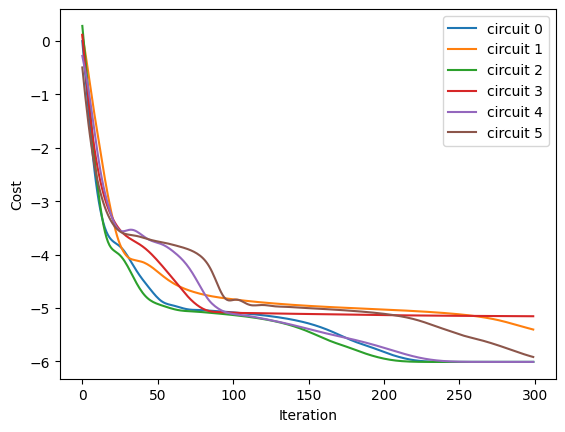

In [10]:
# use vvag to get the losses and gradients with different random circuit instances
QAOA_vvag = K.jit(
    tc.backend.vvag(QAOAansatz, argnums=0, vectorized_argnums=0), static_argnums=(1, 2)
)

params = K.implicit_randn(
    shape=[ncircuits, 2 * nlayers], stddev=0.1
)  # initial parameters
opt = K.optimizer(tf.keras.optimizers.Adam(1e-2))

list_of_loss = [[] for i in range(ncircuits)]

for i in range(300):
    loss, grads = QAOA_vvag(params, example_graph)
    params = opt.update(grads, params)  # gradient descent

    # visualise the progress
    clear_output(wait=True)
    list_of_loss = np.hstack((list_of_loss, K.numpy(loss)[:, np.newaxis]))
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    for index in range(ncircuits):
        plt.plot(range(i + 1), list_of_loss[index])
    legend = ["circuit %d" % leg for leg in range(ncircuits)]
    plt.legend(legend)
    plt.show()

Results: After inputing the optimized parameters back to the ansatz circuit, we can measure the probablitiy distribution of the quantum states. The states with highest probability are supposed to be the ones corresponding to Max Cut

In [11]:
# print all results
for num_circuit in range(ncircuits):
    c = QAOAansatz(params=params[num_circuit], g=example_graph, return_circuit=True)
    loss = QAOAansatz(params=params[num_circuit], g=example_graph)

    # find the states with max probabilities
    probs = K.numpy(c.probability()).round(decimals=4)
    index = np.where(probs == max(probs))[0]
    states = []
    for i in index:
        states.append(f"{bin(i)[2:]:0>{c._nqubits}}")
    print("Circuit #%d" % num_circuit)
    print("cost:", K.numpy(loss), "\nbit strings:", states, "\n")

Circuit #0
cost: -6.0114803 
bit strings: ['01010101', '10101010'] 

Circuit #1
cost: -5.412241 
bit strings: ['01010101', '10101010'] 

Circuit #2
cost: -6.011486 
bit strings: ['01010101', '10101010'] 

Circuit #3
cost: -5.1561985 
bit strings: ['01010101', '10101010'] 

Circuit #4
cost: -6.011451 
bit strings: ['01010101', '10101010'] 

Circuit #5
cost: -5.9262056 
bit strings: ['01010101', '10101010'] 

